In [3]:
import pickle
import numpy as np
import os

# ==========================================
# 1. 参数设置
# ==========================================
n = 5000  # 切换为 100 时，代码会自动加载 n100 的 RHGD 文件
d = 50
r = 20
seed = 7270
base_path = r'C:\Users\24300\Desktop\Ada_S\results'

# ==========================================
# 2. 加载 AdaRHD-S 数据 (Single-loop)
# ==========================================
s_file = os.path.join(base_path, f'simple_n{n}d{d}r{r}_AdaRHD_S_seed{seed}.pickle')
with open(s_file, 'rb') as h:
    data_s = pickle.load(h)

AdaRHD_S_loss = np.array(data_s['loss_upper']).reshape(-1, 1)
AdaRHD_S_runtime = np.cumsum(np.array(data_s['runtime']))
AdaRHD_S_hg_error = np.array(data_s['hg_error']).reshape(-1, 1)
AdaRHD_S_gradnorm = np.array(data_s['hg_norm']).reshape(-1, 1)

print(f"Loaded AdaRHD-S:  {len(AdaRHD_S_loss)} epochs")

# ==========================================
# 3. 加载 AdaRHD-CG 数据 (Double-loop CG)
# ==========================================
cg_file = os.path.join(base_path, f'simple_n{n}d{d}r{r}_AdaRHD_cg_lr0.5.pickle')
with open(cg_file, 'rb') as h:
    data_cg = pickle.load(h)

AdaRHD_CG_loss = np.array(data_cg['loss_upper'][0]).reshape(-1, 1)
AdaRHD_CG_runtime = np.cumsum(np.array(data_cg['runtime'][0]))
AdaRHD_CG_hg_error = np.array(data_cg['hg_error'][0]).reshape(-1, 1)
AdaRHD_CG_gradnorm = np.array(data_cg['hg_norm'][0]).reshape(-1, 1)

print(f"Loaded AdaRHD-CG: {len(AdaRHD_CG_loss)} epochs")

# ==========================================
# 4. 加载 AdaRHD-GD 数据 (Double-loop GD)
# ==========================================
gd_file = os.path.join(base_path, f'simple_n{n}d{d}r{r}_AdaRHD_gd_lr0.5.pickle')

if os.path.exists(gd_file):
    with open(gd_file, 'rb') as h:
        data_gd = pickle.load(h)
    AdaRHD_GD_loss = np.array(data_gd['loss_upper'][0]).reshape(-1, 1)
    AdaRHD_GD_runtime = np.cumsum(np.array(data_gd['runtime'][0]))
    AdaRHD_GD_hg_error = np.array(data_gd['hg_error'][0]).reshape(-1, 1)
    AdaRHD_GD_gradnorm = np.array(data_gd['hg_norm'][0]).reshape(-1, 1)
    print(f"Loaded AdaRHD-GD: {len(AdaRHD_GD_loss)} epochs")

# ==========================================
# 5. 加载 RHGD 数据 (新增: 自动对齐 n)
# ==========================================

# --- RHGD loweriter 20 ---
rhgd20_file = os.path.join(base_path, f'simple_n{n}d{d}r{r}_RHGD_lr0.5_loweriter20.pickle')
with open(rhgd20_file, 'rb') as h:
    data_rhgd20 = pickle.load(h)
# RHGD 通常是单循环存储结构，若报错请微调索引
RHGD20_loss = np.array(data_rhgd20['loss_upper']).reshape(-1, 1)
RHGD20_runtime = np.cumsum(np.array(data_rhgd20['runtime']))
RHGD20_hg_error = np.array(data_rhgd20['hg_error']).reshape(-1, 1)
print(f"Loaded RHGD-20:  {len(RHGD20_loss)} epochs")

# --- RHGD loweriter 50 ---
rhgd50_file = os.path.join(base_path, f'simple_n{n}d{d}r{r}_RHGD_lr0.5_loweriter50.pickle')
with open(rhgd50_file, 'rb') as h:
    data_rhgd50 = pickle.load(h)
RHGD50_loss = np.array(data_rhgd50['loss_upper']).reshape(-1, 1)
RHGD50_runtime = np.cumsum(np.array(data_rhgd50['runtime']))
RHGD50_hg_error = np.array(data_rhgd50['hg_error']).reshape(-1, 1)
print(f"Loaded RHGD-50:  {len(RHGD50_loss)} epochs")

# ==========================================
# 6. 数据对比表格
# ==========================================
print("-" * 50)
print(f"{'Method':<15} | {'Final Loss':<12} | {'Time (s)':<10}")
print("-" * 50)
print(f"{'AdaRHD-S':<15} | {-AdaRHD_S_loss[-1][0]:.6f} | {AdaRHD_S_runtime[-1]:.4f}")
print(f"{'AdaRHD-CG':<15} | {-AdaRHD_CG_loss[-1][0]:.6f} | {AdaRHD_CG_runtime[-1]:.4f}")
if 'AdaRHD_GD_loss' in locals():
    print(f"{'AdaRHD-GD':<15} | {-AdaRHD_GD_loss[-1][0]:.6f} | {AdaRHD_GD_runtime[-1]:.4f}")
print(f"{'RHGD-20':<15} | {-RHGD20_loss[-1][0]:.6f} | {RHGD20_runtime[-1]:.4f}")
print(f"{'RHGD-50':<15} | {-RHGD50_loss[-1][0]:.6f} | {RHGD50_runtime[-1]:.4f}")

Loaded AdaRHD-S:  8675 epochs
Loaded AdaRHD-CG: 611 epochs
Loaded AdaRHD-GD: 565 epochs
Loaded RHGD-20:  201 epochs
Loaded RHGD-50:  201 epochs
--------------------------------------------------
Method          | Final Loss   | Time (s)  
--------------------------------------------------
AdaRHD-S        | 0.105424 | 38.4573
AdaRHD-CG       | 0.090143 | 9.3977
AdaRHD-GD       | 0.072987 | 6.0523
RHGD-20         | 0.044173 | 5.9442
RHGD-50         | 0.044267 | 10.3689


C:\Users\24300\AppData\Local\Temp\ipykernel_7240\3510065264.py:35: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  AdaRHD_CG_loss = np.array(data_cg['loss_upper'][0]).reshape(-1, 1)
C:\Users\24300\AppData\Local\Temp\ipykernel_7240\3510065264.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  AdaRHD_CG_runtime = np.cumsum(np.array(data_cg['runtime'][0]))
C:\Users\24300\AppData\Local\Temp\ipykernel_7240\3510065264.py:37: DeprecationWarning: __array__ implementation doesn't ac

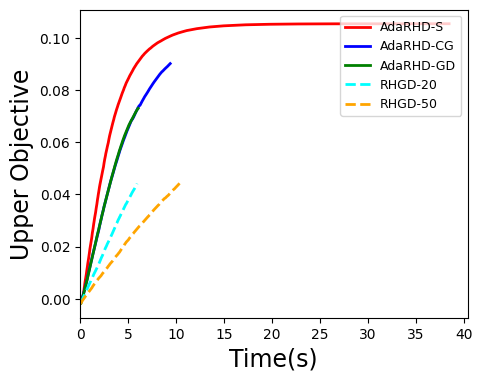

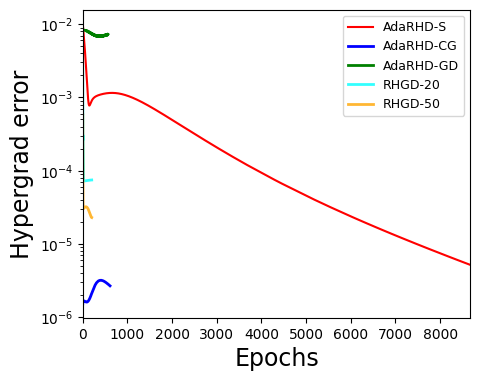

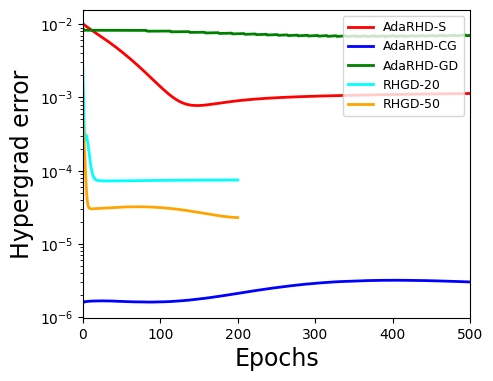

三张 PDF 图像已全部保存至: C:\Users\24300\Desktop\Ada_S\fig


In [4]:
import matplotlib.pyplot as plt
import os

# 确保图片保存目录存在
fig_path = r'C:\Users\24300\Desktop\Ada_S\fig'
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

# --- 通用设置 ---
lw = 2  # 线宽

# ---------------------------------------------------------
# 图 1: Upper Objective vs Time
# ---------------------------------------------------------
plt.figure(figsize=(5, 4))
# 原有算法 (实线)
plt.plot(AdaRHD_S_runtime, -AdaRHD_S_loss, color='red', label='AdaRHD-S', linewidth=lw)
plt.plot(AdaRHD_CG_runtime, -AdaRHD_CG_loss, color='blue', label='AdaRHD-CG', linewidth=lw)
if 'AdaRHD_GD_loss' in locals():
    plt.plot(AdaRHD_GD_runtime, -AdaRHD_GD_loss, color='green', label='AdaRHD-GD', linewidth=lw)

# 新增 RHGD (虚线以区分)
plt.plot(RHGD20_runtime, -RHGD20_loss, color='cyan', label='RHGD-20', linewidth=lw, linestyle='--')
plt.plot(RHGD50_runtime, -RHGD50_loss, color='orange', label='RHGD-50', linewidth=lw, linestyle='--')

# 动态计算最大时间
all_times = [AdaRHD_S_runtime[-1], AdaRHD_CG_runtime[-1], RHGD20_runtime[-1], RHGD50_runtime[-1]]
if 'AdaRHD_GD_runtime' in locals(): all_times.append(AdaRHD_GD_runtime[-1])

plt.xlim([0, max(all_times) * 1.05]) 
plt.xlabel('Time(s)', fontsize=17)
plt.ylabel('Upper Objective', fontsize=17)
plt.legend(fontsize=9, loc='upper right') # 缩小字号防止遮挡
plt.grid(False)

plt.savefig(f'{fig_path}/simple_{n}_{d}_{r}_upper_obj_time_all.pdf', format='pdf', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 图 2: Hypergrad error vs Epochs (完整版本)
# ---------------------------------------------------------
plt.figure(figsize=(5, 4))
# 原有算法
plt.semilogy(range(len(AdaRHD_S_hg_error)), AdaRHD_S_hg_error, color='red', label='AdaRHD-S', linewidth=1.5)
plt.semilogy(range(len(AdaRHD_CG_hg_error)), AdaRHD_CG_hg_error, color='blue', label='AdaRHD-CG', linewidth=lw)
if 'AdaRHD_GD_hg_error' in locals():
    plt.semilogy(range(len(AdaRHD_GD_hg_error)), AdaRHD_GD_hg_error, color='green', label='AdaRHD-GD', linewidth=lw)

# 新增 RHGD
plt.semilogy(range(len(RHGD20_hg_error)), RHGD20_hg_error, color='cyan', label='RHGD-20', linewidth=lw, alpha=0.8)
plt.semilogy(range(len(RHGD50_hg_error)), RHGD50_hg_error, color='orange', label='RHGD-50', linewidth=lw, alpha=0.8)

# 自动适配横坐标
all_lens = [len(AdaRHD_S_hg_error), len(AdaRHD_CG_hg_error), len(RHGD20_hg_error), len(RHGD50_hg_error)]
plt.xlim([0, max(all_lens)])
plt.xlabel('Epochs', fontsize=17)
plt.ylabel('Hypergrad error', fontsize=17)
plt.legend(fontsize=9, loc='upper right')
plt.grid(False)

plt.savefig(f'{fig_path}/simple_{n}_{d}_{r}_hypergrad_error_full_all.pdf', format='pdf', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 图 3: Hypergrad error vs Epochs (局部放大: 0-500)
# ---------------------------------------------------------
plt.figure(figsize=(5, 4))
plt.semilogy(range(len(AdaRHD_S_hg_error)), AdaRHD_S_hg_error, color='red', label='AdaRHD-S', linewidth=lw)
plt.semilogy(range(len(AdaRHD_CG_hg_error)), AdaRHD_CG_hg_error, color='blue', label='AdaRHD-CG', linewidth=lw)
if 'AdaRHD_GD_hg_error' in locals():
    plt.semilogy(range(len(AdaRHD_GD_hg_error)), AdaRHD_GD_hg_error, color='green', label='AdaRHD-GD', linewidth=lw)

# 新增 RHGD 细节
plt.semilogy(range(len(RHGD20_hg_error)), RHGD20_hg_error, color='cyan', label='RHGD-20', linewidth=lw)
plt.semilogy(range(len(RHGD50_hg_error)), RHGD50_hg_error, color='orange', label='RHGD-50', linewidth=lw)

plt.xlim([0, 500]) 
plt.xlabel('Epochs', fontsize=17)
plt.ylabel('Hypergrad error', fontsize=17)
plt.legend(fontsize=9, loc='upper right')
plt.grid(False)

plt.savefig(f'{fig_path}/simple_{n}_{d}_{r}_hypergrad_error_zoom500_all.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(f"三张 PDF 图像已全部保存至: {fig_path}")